# Dual YOLO Video Inference Pipeline

This notebook demonstrates how to use the dual YOLO inference system to:
1. Process video clips with both standard YOLOv8 and fine-tuned MOCS models
2. Detect construction sites based on equipment presence
3. Fuse and aggregate results across frames
4. Process entire directories of videos

## Features
- **Dual Model Inference**: Standard YOLOv8 for general object detection + MOCS model for construction equipment
- **Construction Site Detection**: Automatically identifies construction sites based on equipment (excludes workers and other vehicles)
- **Customizable Aggregation**: Multiple methods to aggregate frame-level results to video-level insights
- **Batch Processing**: Process entire directories of videos efficiently
- **Comprehensive Results**: JSON and CSV outputs with detailed per-video reports

## 1. Setup and Imports

In [74]:
# Install required packages (if needed)
# !pip install ultralytics opencv-python pandas tqdm matplotlib seaborn pillow

import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from IPython.display import Video, display, HTML
import cv2

# Add current directory to path
sys.path.append(str(Path.cwd()))

# Import our modules
from video_frame_extractor import VideoFrameExtractor
from dual_yolo_inference import DualYOLOInference, CONSTRUCTION_EQUIPMENT
from output_fusion import OutputFusion, AggregationMethod, create_fusion_engine
from batch_processor import BatchVideoProcessor, process_video_directory

print("All modules imported successfully!")
print(f"Construction equipment classes: {len(CONSTRUCTION_EQUIPMENT)}")
print(f"Equipment: {', '.join(sorted(CONSTRUCTION_EQUIPMENT))}")

All modules imported successfully!
Construction equipment classes: 11
Equipment: Bulldozer, Concrete mixer, Crane, Excavator, Hanging head, Loader, Pile driving, Pump truck, Roller, Static crane, Truck


## 2. Configuration

In [75]:
# Configuration parameters
CONFIG = {
    # Model paths
    'standard_model': '../YOLOv8/yolov8n.pt',  # Standard YOLOv8 nano model
    'mocs_model': '../YOLOv8/runs/detect/mocs_yolov8n_train/weights/best.pt',  # Fine-tuned MOCS model
    
    # Inference settings
    'conf_threshold': 0.5,  # Confidence threshold for detections
    'frame_skip': 30,  # Process every 30th frame (~1 fps for 30fps video)
    'device': 'cuda',  # 'cuda' or 'cpu'
    
    # Aggregation settings
    'aggregation_method': 'average_confidence',  # Options: max_confidence, average_confidence, majority_vote, weighted_average, threshold_percentage
    'min_detection_percentage': 10.0,  # Minimum % of frames to include detection in results
    'construction_threshold': 0.7,  # Minimum % of frames with equipment to classify as construction site
    
    # I/O settings
    'video_directory': 'D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/video_chunks',  # Directory containing test videos
    'output_directory': './results',  # Where to save results
}

# Print configuration
print("Configuration:")
print("=" * 60)
for key, value in CONFIG.items():
    print(f"{key:30s}: {value}")
print("=" * 60)

Configuration:
standard_model                : ../YOLOv8/yolov8n.pt
mocs_model                    : ../YOLOv8/runs/detect/mocs_yolov8n_train/weights/best.pt
conf_threshold                : 0.5
frame_skip                    : 30
device                        : cuda
aggregation_method            : average_confidence
min_detection_percentage      : 10.0
construction_threshold        : 0.7
video_directory               : D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/video_chunks
output_directory              : ./results


## 3. Single Video Processing Example

In [76]:
# Example: Process a single video

# Path to a test video
test_video_path = "D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/video_chunks/test_traffic_vid_1_chunk_0000.mp4"  # Update this path

# Initialize components
frame_extractor = VideoFrameExtractor(frame_skip=CONFIG['frame_skip'])
inference_engine = DualYOLOInference(
    standard_model_path=CONFIG['standard_model'],
    mocs_model_path=CONFIG['mocs_model'],
    conf_threshold=CONFIG['conf_threshold'],
    device=CONFIG['device']
)
fusion_engine = create_fusion_engine(
    aggregation_method=CONFIG['aggregation_method'],
    min_detection_percentage=CONFIG['min_detection_percentage'],
    construction_threshold=CONFIG['construction_threshold']
)

# Check if video exists
if Path(test_video_path).exists():
    # Get video info
    video_info = frame_extractor.get_video_info(test_video_path)
    print(f"\nVideo Information:")
    for key, value in video_info.items():
        print(f"  {key}: {value}")
    
    # Extract frames
    print(f"\nExtracting frames (every {CONFIG['frame_skip']} frames)...")
    frames = list(frame_extractor.extract_frames(test_video_path))
    print(f"Extracted {len(frames)} frames")
    
    # Perform inference
    print("\nPerforming inference on frames...")
    frame_results = inference_engine.infer_frames(frames)
    
    # Fuse results
    print("\nFusing results...")
    video_result = fusion_engine.fuse_video_results(
        video_path=test_video_path,
        frame_results=frame_results,
        video_metadata=video_info
    )
    
    print("\n" + "=" * 60)
    print("VIDEO INFERENCE RESULTS")
    print("=" * 60)
    print(f"Video: {Path(test_video_path).name}")
    print(f"Total frames analyzed: {video_result.total_frames}")
    print(f"\nConstruction Site Detection:")
    print(f"  Is construction site: {video_result.is_construction_site}")
    print(f"  Confidence: {video_result.construction_confidence:.2%}")
    print(f"  Equipment detected: {', '.join(video_result.construction_equipment) if video_result.construction_equipment else 'None'}")
    print(f"\nStandard YOLO Detections: {len(video_result.standard_detections)} unique classes")
    print(f"MOCS Detections: {len(video_result.mocs_detections)} unique classes")
    print("=" * 60)
    
else:
    print(f"Test video not found: {test_video_path}")
    print("Please update the test_video_path variable with a valid video file path.")

INFO:dual_yolo_inference:Loading standard YOLO model from ../YOLOv8/yolov8n.pt
INFO:dual_yolo_inference:Loading MOCS model from ../YOLOv8/runs/detect/mocs_yolov8n_train/weights/best.pt
INFO:dual_yolo_inference:Loading MOCS model from ../YOLOv8/runs/detect/mocs_yolov8n_train/weights/best.pt
INFO:video_frame_extractor:Video info for test_traffic_vid_1_chunk_0000.mp4: {'fps': 30.0, 'frame_count': 300, 'width': 852, 'height': 480, 'duration': 10.0, 'codec': 875967080}
INFO:video_frame_extractor:Video info for test_traffic_vid_1_chunk_0000.mp4: {'fps': 30.0, 'frame_count': 300, 'width': 852, 'height': 480, 'duration': 10.0, 'codec': 875967080}



Video Information:
  fps: 30.0
  frame_count: 300
  width: 852
  height: 480
  duration: 10.0
  codec: 875967080

Extracting frames (every 30 frames)...


INFO:video_frame_extractor:Extracted 10 frames from 300 total frames
INFO:dual_yolo_inference:Processing frame 0
INFO:dual_yolo_inference:Processing frame 0


Extracted 10 frames

Performing inference on frames...


INFO:dual_yolo_inference:Processing frame 30
INFO:dual_yolo_inference:Processing frame 60
INFO:dual_yolo_inference:Processing frame 60
INFO:dual_yolo_inference:Processing frame 90
INFO:dual_yolo_inference:Processing frame 90
INFO:dual_yolo_inference:Processing frame 120
INFO:dual_yolo_inference:Processing frame 120
INFO:dual_yolo_inference:Processing frame 150
INFO:dual_yolo_inference:Processing frame 150
INFO:dual_yolo_inference:Processing frame 180
INFO:dual_yolo_inference:Processing frame 180
INFO:dual_yolo_inference:Processing frame 210
INFO:dual_yolo_inference:Processing frame 210
INFO:dual_yolo_inference:Processing frame 240
INFO:dual_yolo_inference:Processing frame 240
INFO:dual_yolo_inference:Processing frame 270
INFO:dual_yolo_inference:Processing frame 270
INFO:output_fusion:Fusing results for D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/video_chunks/test_traffic_vid_1_chunk_0000.mp4 (10 frames)
INFO:output_fusion:Construction site: False (confidence


Fusing results...

VIDEO INFERENCE RESULTS
Video: test_traffic_vid_1_chunk_0000.mp4
Total frames analyzed: 10

Construction Site Detection:
  Is construction site: False
  Confidence: 0.00%
  Equipment detected: None

Standard YOLO Detections: 1 unique classes
MOCS Detections: 1 unique classes


## 4. Visualize Detection Results

In [77]:
# Visualize top detections from single video processing

if 'video_result' in locals():
    # Top standard detections
    print("Top 10 Standard YOLO Detections:")
    print("-" * 80)
    print(f"{'Class':<25} {'Confidence':<12} {'Frame %':<10} {'Count':<8}")
    print("-" * 80)
    
    for detection in video_result.standard_detections[:10]:
        print(f"{detection.class_name:<25} {detection.confidence:<12.2%} "
              f"{detection.detection_percentage:<10.1f} {detection.detection_count:<8}")
    
    print("\n" + "=" * 80)
    print("Top MOCS Detections (Construction Equipment):")
    print("-" * 80)
    print(f"{'Class':<25} {'Confidence':<12} {'Frame %':<10} {'Count':<8}")
    print("-" * 80)
    
    for detection in video_result.mocs_detections[:10]:
        print(f"{detection.class_name:<25} {detection.confidence:<12.2%} "
              f"{detection.detection_percentage:<10.1f} {detection.detection_count:<8}")

Top 10 Standard YOLO Detections:
--------------------------------------------------------------------------------
Class                     Confidence   Frame %    Count   
--------------------------------------------------------------------------------
car                       74.38%       470.0      47      

Top MOCS Detections (Construction Equipment):
--------------------------------------------------------------------------------
Class                     Confidence   Frame %    Count   
--------------------------------------------------------------------------------
Other vehicle             75.53%       220.0      22      


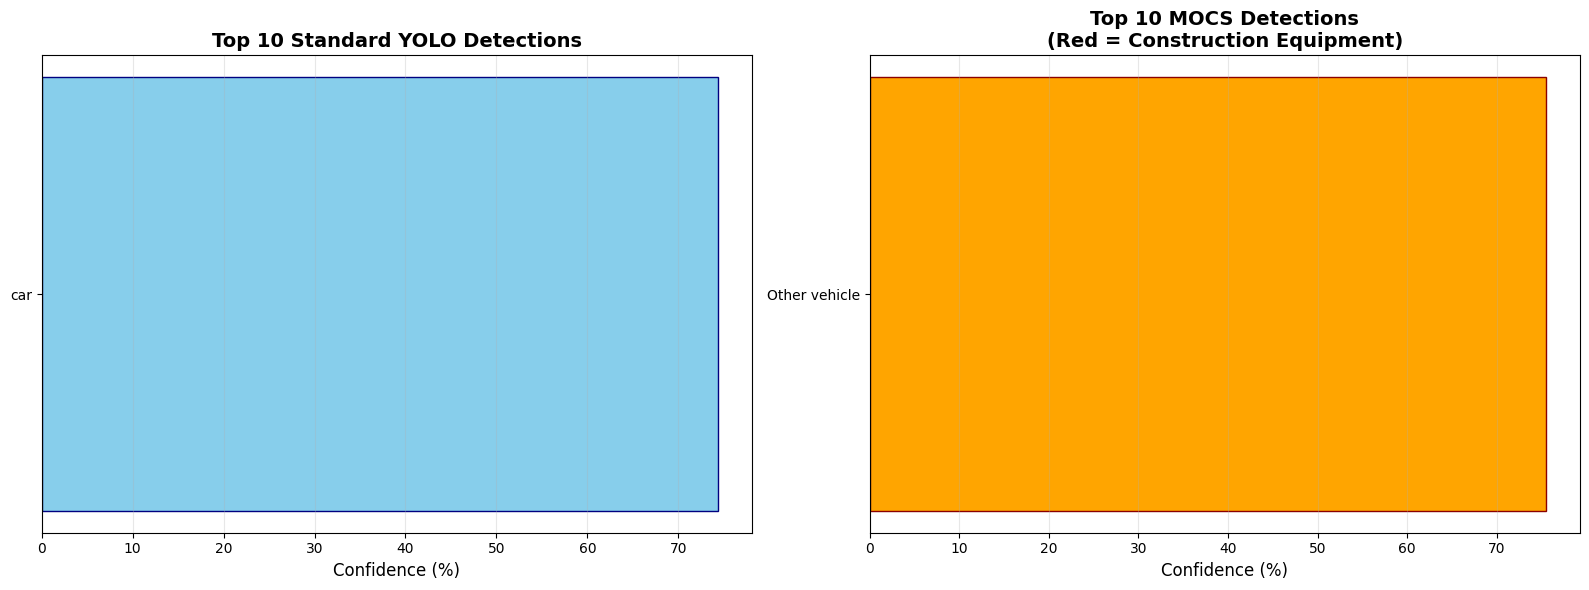

In [78]:
# Plot detection distribution

if 'video_result' in locals() and len(video_result.standard_detections) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Standard detections
    ax1 = axes[0]
    top_standard = video_result.standard_detections[:10]
    classes = [d.class_name for d in top_standard]
    confidences = [d.confidence * 100 for d in top_standard]
    
    ax1.barh(classes, confidences, color='skyblue', edgecolor='navy')
    ax1.set_xlabel('Confidence (%)', fontsize=12)
    ax1.set_title('Top 10 Standard YOLO Detections', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()
    
    # MOCS detections
    ax2 = axes[1]
    if len(video_result.mocs_detections) > 0:
        top_mocs = video_result.mocs_detections[:10]
        mocs_classes = [d.class_name for d in top_mocs]
        mocs_confidences = [d.confidence * 100 for d in top_mocs]
        
        colors = ['red' if c in CONSTRUCTION_EQUIPMENT else 'orange' for c in mocs_classes]
        ax2.barh(mocs_classes, mocs_confidences, color=colors, edgecolor='darkred')
        ax2.set_xlabel('Confidence (%)', fontsize=12)
        ax2.set_title('Top 10 MOCS Detections\n(Red = Construction Equipment)', 
                     fontsize=14, fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        ax2.invert_yaxis()
    else:
        ax2.text(0.5, 0.5, 'No MOCS detections', 
                ha='center', va='center', fontsize=14, transform=ax2.transAxes)
        ax2.set_xlim(0, 1)
    
    plt.tight_layout()
    plt.show()

## 5. Visualize Sample Frames with Detections

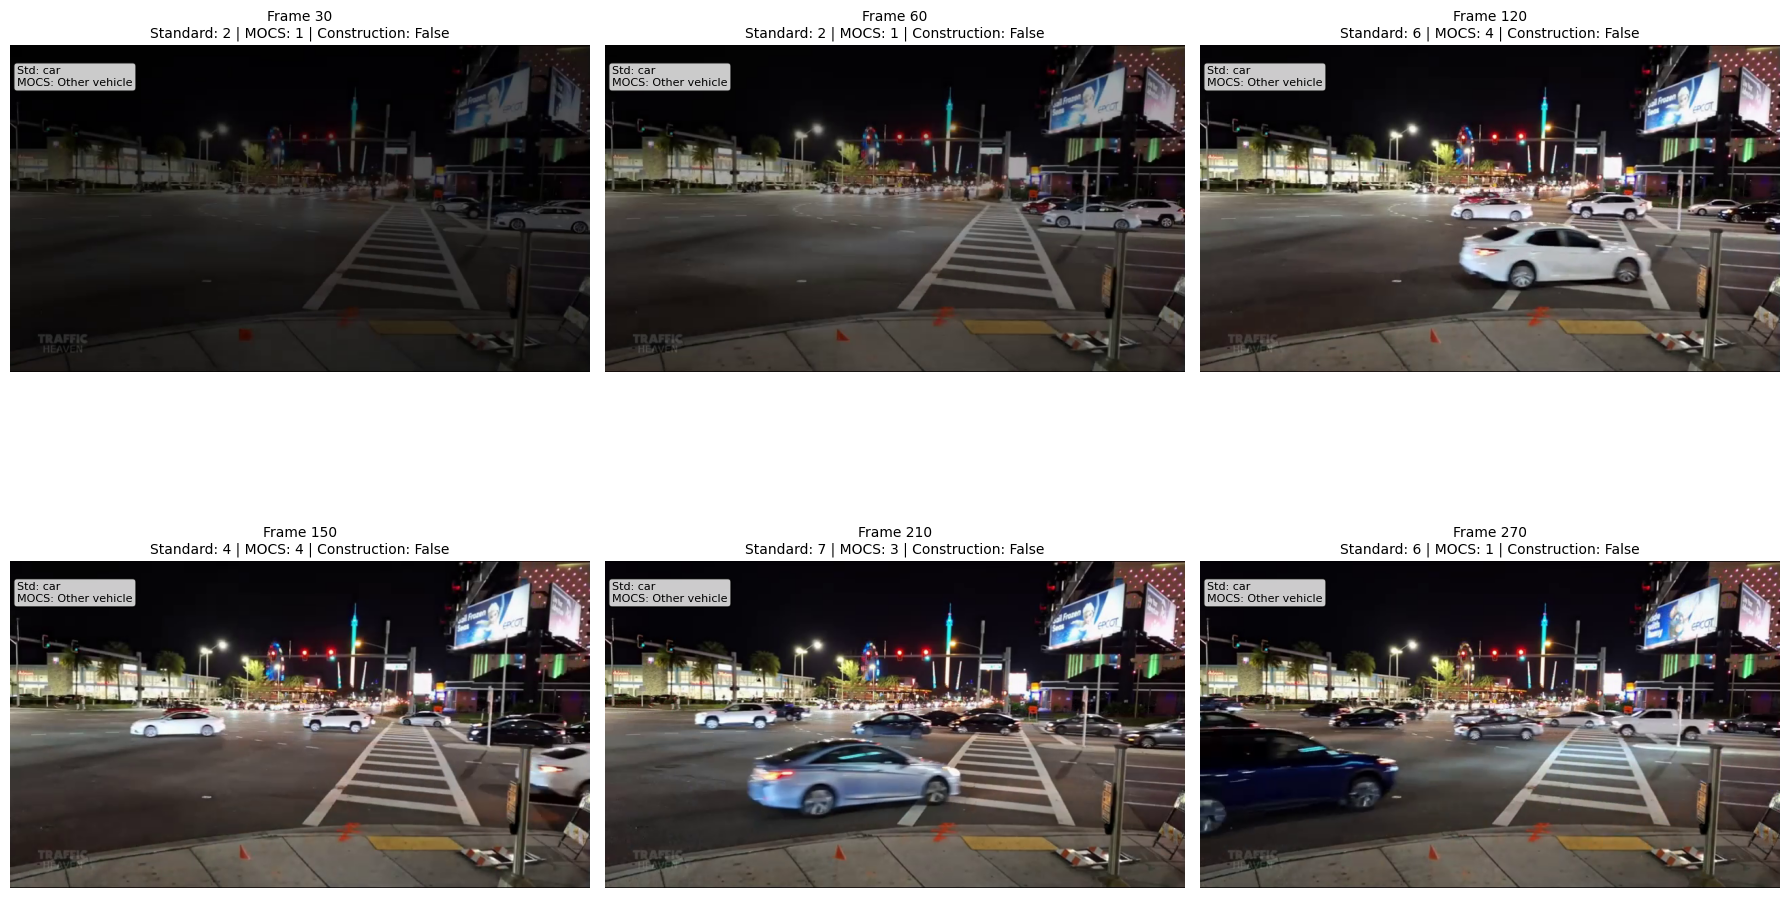

In [79]:
# Visualize a few frames with bounding boxes

if 'frames' in locals() and 'frame_results' in locals():
    # Select a few interesting frames (those with detections)
    frames_with_detections = [
        (i, frames[i], frame_results[i]) 
        for i in range(len(frame_results))
        if len(frame_results[i].standard_detections) > 0 or len(frame_results[i].mocs_detections) > 0
    ]
    
    if len(frames_with_detections) > 0:
        # Display up to 6 frames
        num_samples = min(6, len(frames_with_detections))
        sample_indices = np.linspace(0, len(frames_with_detections)-1, num_samples, dtype=int)
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        for idx, sample_idx in enumerate(sample_indices):
            i, (frame_num, frame), result = frames_with_detections[sample_idx]
            
            # Convert BGR to RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            ax = axes[idx]
            ax.imshow(frame_rgb)
            ax.set_title(f'Frame {frame_num}\n'
                        f'Standard: {len(result.standard_detections)} | '
                        f'MOCS: {len(result.mocs_detections)} | '
                        f'Construction: {result.is_construction_site}',
                        fontsize=10)
            ax.axis('off')
            
            # Draw bounding boxes (simplified - just count)
            detection_text = []
            if result.standard_detections:
                detection_text.append(f"Std: {', '.join(set(d.class_name for d in result.standard_detections[:3]))}")
            if result.mocs_detections:
                detection_text.append(f"MOCS: {', '.join(set(d.class_name for d in result.mocs_detections[:3]))}")
            
            if detection_text:
                ax.text(10, 30, '\n'.join(detection_text), 
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                       fontsize=8, verticalalignment='top')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No frames with detections found in the processed frames.")
else:
    print("No frame data available. Please run the single video processing example first.")

## 6. Batch Processing - Process Directory of Videos

In [80]:
# Process all videos in a directory

# Create output directory
output_dir = Path(CONFIG['output_directory'])
output_dir.mkdir(parents=True, exist_ok=True)

# Check if video directory exists
video_dir = Path(CONFIG['video_directory'])

if video_dir.exists():
    print(f"Processing all videos in: {video_dir}")
    print(f"Results will be saved to: {output_dir}")
    print("\nStarting batch processing...\n")
    
    # Process directory
    results = process_video_directory(
        directory_path=str(video_dir),
        standard_model_path=CONFIG['standard_model'],
        mocs_model_path=CONFIG['mocs_model'],
        output_dir=str(output_dir),
        conf_threshold=CONFIG['conf_threshold'],
        frame_skip=CONFIG['frame_skip'],
        aggregation_method=CONFIG['aggregation_method'],
        min_detection_percentage=CONFIG['min_detection_percentage'],
        construction_threshold=CONFIG['construction_threshold'],
        device=CONFIG['device']
    )
    
    print(f"\n✓ Processed {len(results)} videos successfully!")
    print(f"✓ Results saved to: {output_dir}")
    
else:
    print(f"Video directory not found: {video_dir}")
    print("Please create the directory and add video files, or update CONFIG['video_directory']")

INFO:dual_yolo_inference:Loading standard YOLO model from ../YOLOv8/yolov8n.pt
INFO:dual_yolo_inference:Loading MOCS model from ../YOLOv8/runs/detect/mocs_yolov8n_train/weights/best.pt
INFO:dual_yolo_inference:Loading MOCS model from ../YOLOv8/runs/detect/mocs_yolov8n_train/weights/best.pt
INFO:batch_processor:Found 60 video files in D:\Projects\UrbanNoiseClassifier\project\pre_inference\processed_media\video_chunks
INFO:batch_processor:Found 60 video files in D:\Projects\UrbanNoiseClassifier\project\pre_inference\processed_media\video_chunks


Processing all videos in: D:\Projects\UrbanNoiseClassifier\project\pre_inference\processed_media\video_chunks
Results will be saved to: results

Starting batch processing...



Processing videos:   0%|          | 0/60 [00:00<?, ?it/s]INFO:batch_processor:Processing video: D:\Projects\UrbanNoiseClassifier\project\pre_inference\processed_media\video_chunks\test_traffic_vid_1_chunk_0000.mp4
INFO:video_frame_extractor:Video info for test_traffic_vid_1_chunk_0000.mp4: {'fps': 30.0, 'frame_count': 300, 'width': 852, 'height': 480, 'duration': 10.0, 'codec': 875967080}
INFO:batch_processor:Processing video: D:\Projects\UrbanNoiseClassifier\project\pre_inference\processed_media\video_chunks\test_traffic_vid_1_chunk_0000.mp4
INFO:video_frame_extractor:Video info for test_traffic_vid_1_chunk_0000.mp4: {'fps': 30.0, 'frame_count': 300, 'width': 852, 'height': 480, 'duration': 10.0, 'codec': 875967080}
INFO:video_frame_extractor:Extracted 10 frames from 300 total frames
INFO:batch_processor:Extracted 10 frames
INFO:video_frame_extractor:Extracted 10 frames from 300 total frames
INFO:batch_processor:Extracted 10 frames
INFO:dual_yolo_inference:Processing frame 0
INFO:dual


✓ Processed 60 videos successfully!
✓ Results saved to: results


## 7. Analyze Batch Results

In [81]:
# Analyze results from batch processing

if 'results' in locals() and len(results) > 0:
    # Create summary dataframe
    summary_data = []
    for result in results:
        # Format all standard detections (top 5)
        standard_classes = [f"{d.class_name} ({d.confidence:.1%})" 
                           for d in result.standard_detections[:5]]
        
        # Format all MOCS detections (top 5)
        mocs_classes = [f"{d.class_name} ({d.confidence:.1%})" 
                       for d in result.mocs_detections[:5]]
        
        summary_data.append({
            'Video': Path(result.video_path).name,
            'Frames': result.total_frames,
            'Construction Site': 'Yes' if result.is_construction_site else 'No',
            'Construction Confidence': f"{result.construction_confidence:.1%}",
            'Equipment': ', '.join(result.construction_equipment[:3]) if result.construction_equipment else 'None',
            'Standard Detections (Top 5)': '; '.join(standard_classes) if standard_classes else 'None',
            'MOCS Detections (Top 5)': '; '.join(mocs_classes) if mocs_classes else 'None',
        })
    
    df_summary = pd.DataFrame(summary_data)
    
    print("Batch Processing Summary:")
    print("=" * 120)
    display(df_summary)
    print("=" * 120)
    
    # Statistics
    construction_count = sum(1 for r in results if r.is_construction_site)
    print(f"\nConstruction Sites Detected: {construction_count}/{len(results)} "
          f"({construction_count/len(results)*100:.1f}%)")

Batch Processing Summary:


,Video,Frames,Construction Site,Construction Confidence,Equipment,Standard Detections (Top 5),MOCS Detections (Top 5)
0,test_traffic_vid_1_chunk_0000.mp4,10,No,0.0%,None,car (74.4%),Other vehicle (75.5%)
1,test_traffic_vid_1_chunk_0001.mp4,10,No,10.0%,Truck,car (71.0%),Other vehicle (69.4%); Truck (68.7%)
2,test_traffic_vid_1_chunk_0002.mp4,10,No,0.0%,None,car (72.3%),Other vehicle (82.6%)
3,test_traffic_vid_1_chunk_0003.mp4,10,No,10.0%,Crane,car (73.3%),Other vehicle (78.5%); Crane (54.2%)
4,test_traffic_vid_1_chunk_0004.mp4,9,No,0.0%,None,car (74.6%),Other vehicle (79.4%)
5,test_traffic_vid_1_chunk_0005.mp4,9,No,0.0%,None,person (83.3%); car (75.9%),Worker (86.0%); Other vehicle (82.6%)
6,test_traffic_vid_1_chunk_0006.mp4,9,No,0.0%,None,car (76.9%),Other vehicle (81.6%)
7,test_traffic_vid_1_chunk_0007.mp4,9,No,11.1%,Crane,car (78.4%),Other vehicle (80.3%); Crane (51.2%)
8,test_traffic_vid_1_chunk_0008.mp4,8,No,12.5%,Truck,car (75.2%),Other vehicle (70.4%); Truck (59.9%)
9,test_traffic_vid_1_chunk_0009.mp4,8,No,12.5%,Truck,car (71.2%),Other vehicle (69.8%); Truck (61.2%)



Construction Sites Detected: 1/60 (1.7%)


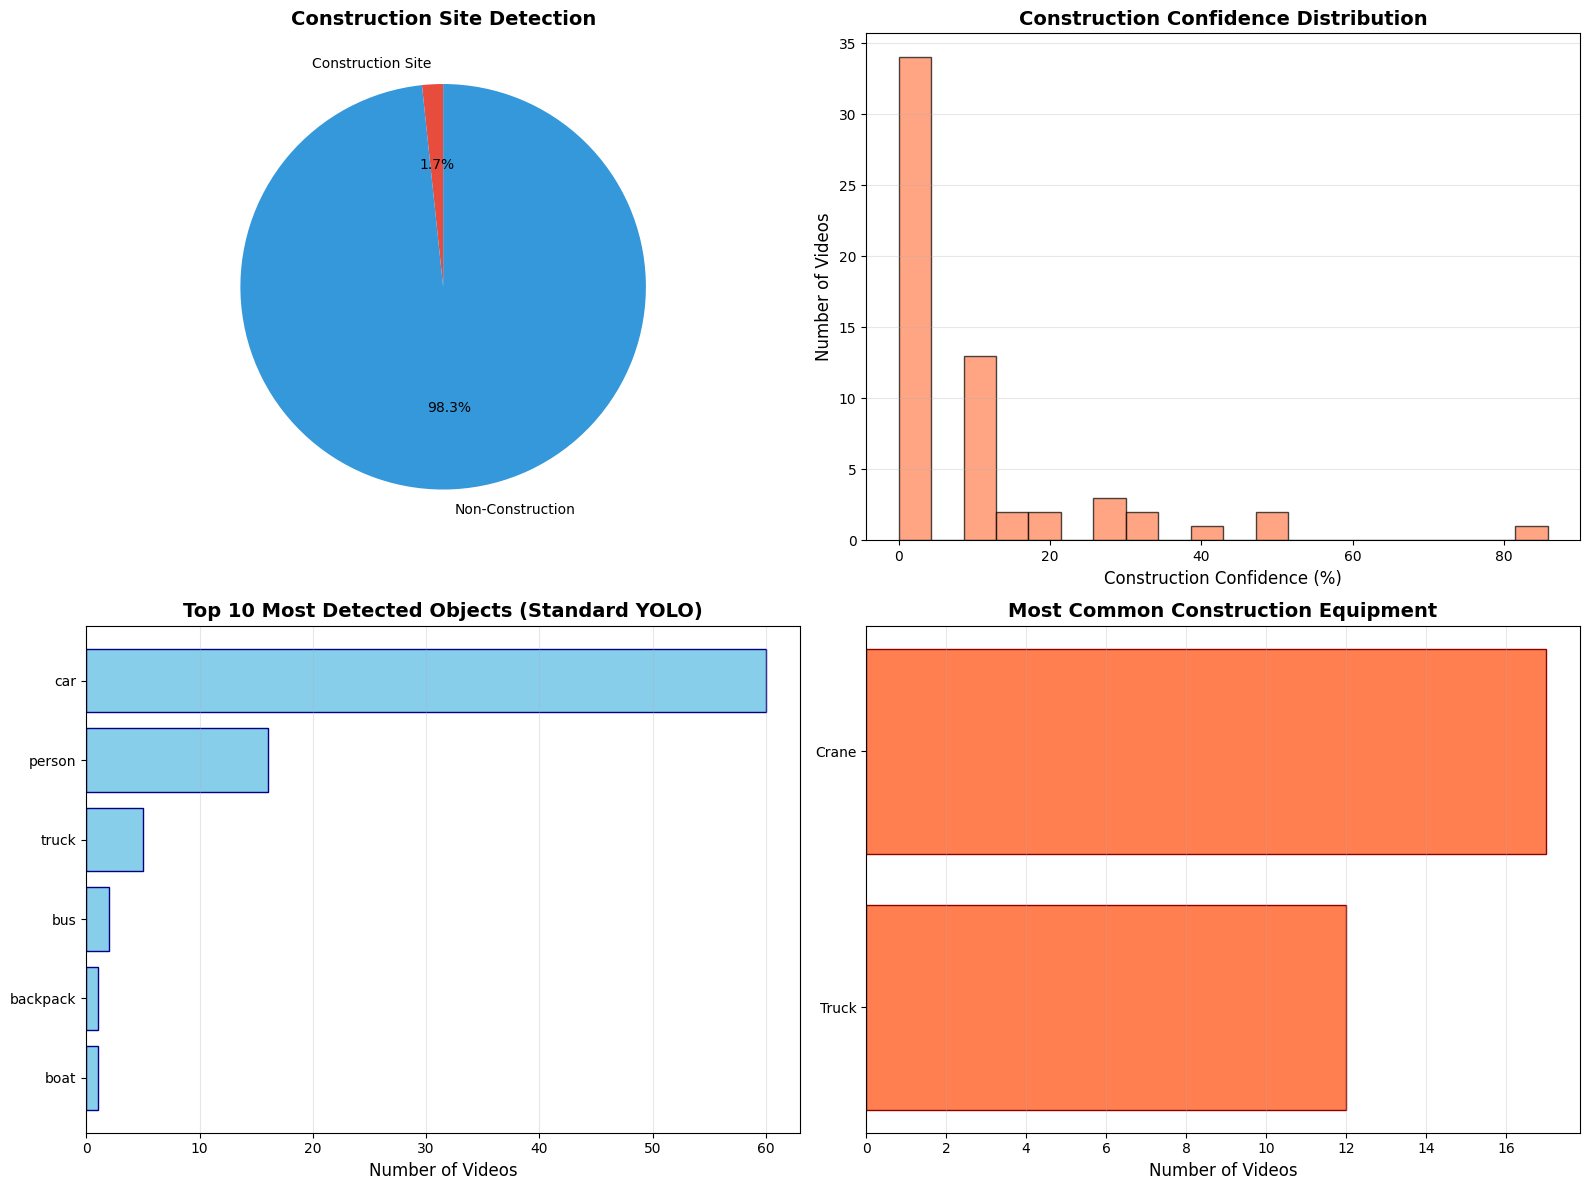

In [82]:
# Visualize batch results

if 'results' in locals() and len(results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Construction site distribution
    ax1 = axes[0, 0]
    construction_counts = [
        sum(1 for r in results if r.is_construction_site),
        sum(1 for r in results if not r.is_construction_site)
    ]
    colors = ['#e74c3c', '#3498db']
    ax1.pie(construction_counts, labels=['Construction Site', 'Non-Construction'], 
           autopct='%1.1f%%', colors=colors, startangle=90)
    ax1.set_title('Construction Site Detection', fontsize=14, fontweight='bold')
    
    # 2. Construction confidence distribution
    ax2 = axes[0, 1]
    construction_confidences = [r.construction_confidence * 100 for r in results]
    ax2.hist(construction_confidences, bins=20, color='coral', edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Construction Confidence (%)', fontsize=12)
    ax2.set_ylabel('Number of Videos', fontsize=12)
    ax2.set_title('Construction Confidence Distribution', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. Most common standard detections
    ax3 = axes[1, 0]
    all_standard_detections = {}
    for result in results:
        for detection in result.standard_detections:
            if detection.class_name not in all_standard_detections:
                all_standard_detections[detection.class_name] = 0
            all_standard_detections[detection.class_name] += 1
    
    if all_standard_detections:
        top_classes = sorted(all_standard_detections.items(), key=lambda x: x[1], reverse=True)[:10]
        classes, counts = zip(*top_classes)
        ax3.barh(classes, counts, color='skyblue', edgecolor='navy')
        ax3.set_xlabel('Number of Videos', fontsize=12)
        ax3.set_title('Top 10 Most Detected Objects (Standard YOLO)', fontsize=14, fontweight='bold')
        ax3.invert_yaxis()
        ax3.grid(axis='x', alpha=0.3)
    
    # 4. Construction equipment frequency
    ax4 = axes[1, 1]
    all_equipment = {}
    for result in results:
        for equipment in result.construction_equipment:
            if equipment not in all_equipment:
                all_equipment[equipment] = 0
            all_equipment[equipment] += 1
    
    if all_equipment:
        top_equipment = sorted(all_equipment.items(), key=lambda x: x[1], reverse=True)[:10]
        equipment_names, equipment_counts = zip(*top_equipment)
        ax4.barh(equipment_names, equipment_counts, color='coral', edgecolor='darkred')
        ax4.set_xlabel('Number of Videos', fontsize=12)
        ax4.set_title('Most Common Construction Equipment', fontsize=14, fontweight='bold')
        ax4.invert_yaxis()
        ax4.grid(axis='x', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No construction equipment detected', 
                ha='center', va='center', fontsize=14, transform=ax4.transAxes)
    
    plt.tight_layout()
    plt.show()

## 8. Compare Aggregation Methods

In [83]:
# Compare different aggregation methods on the same video

if 'frames' in locals() and 'frame_results' in locals():
    aggregation_methods = [
        'max_confidence',
        'average_confidence',
        'majority_vote',
        'weighted_average',
        'threshold_percentage'
    ]
    
    comparison_results = {}
    
    for method in aggregation_methods:
        fusion = create_fusion_engine(
            aggregation_method=method,
            min_detection_percentage=CONFIG['min_detection_percentage'],
            construction_threshold=CONFIG['construction_threshold']
        )
        
        video_result = fusion.fuse_video_results(
            video_path=test_video_path,
            frame_results=frame_results
        )
        
        comparison_results[method] = {
            'is_construction': video_result.is_construction_site,
            'construction_conf': video_result.construction_confidence,
            'num_standard': len(video_result.standard_detections),
            'num_mocs': len(video_result.mocs_detections),
            'top_standard': video_result.standard_detections[0].class_name if video_result.standard_detections else 'None',
            'top_standard_conf': video_result.standard_detections[0].confidence if video_result.standard_detections else 0
        }
    
    # Display comparison
    print("Aggregation Method Comparison:")
    print("=" * 120)
    print(f"{'Method':<25} {'Construction':<15} {'Const. Conf':<15} {'Std Det':<10} {'MOCS Det':<10} {'Top Detection':<20} {'Confidence':<10}")
    print("=" * 120)
    
    for method, data in comparison_results.items():
        print(f"{method:<25} {str(data['is_construction']):<15} "
              f"{data['construction_conf']:<15.2%} {data['num_standard']:<10} "
              f"{data['num_mocs']:<10} {data['top_standard']:<20} "
              f"{data['top_standard_conf']:<10.2%}")
    
    print("=" * 120)

INFO:output_fusion:Fusing results for D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/video_chunks/test_traffic_vid_1_chunk_0000.mp4 (10 frames)
INFO:output_fusion:Construction site: False (confidence: 0.00%)
INFO:output_fusion:Standard detections: 1 unique classes
INFO:output_fusion:MOCS detections: 1 unique classes
INFO:output_fusion:Fusing results for D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/video_chunks/test_traffic_vid_1_chunk_0000.mp4 (10 frames)
INFO:output_fusion:Construction site: False (confidence: 0.00%)
INFO:output_fusion:Standard detections: 1 unique classes
INFO:output_fusion:MOCS detections: 1 unique classes
INFO:output_fusion:Fusing results for D:/Projects/UrbanNoiseClassifier/project/pre_inference/processed_media/video_chunks/test_traffic_vid_1_chunk_0000.mp4 (10 frames)
INFO:output_fusion:Construction site: False (confidence: 0.00%)
INFO:output_fusion:Standard detections: 1 unique classes
INFO:output_fusion:Construc

Aggregation Method Comparison:
Method                    Construction    Const. Conf     Std Det    MOCS Det   Top Detection        Confidence
max_confidence            False           0.00%           1          1          car                  93.48%    
average_confidence        False           0.00%           1          1          car                  74.38%    
majority_vote             False           0.00%           1          1          car                  100.00%   
weighted_average          False           0.00%           1          1          car                  193.06%   
threshold_percentage      False           0.00%           1          1          car                  74.38%    


## 9. Export Results for Further Analysis

In [84]:
# Export detailed results to various formats

if 'results' in locals() and len(results) > 0:
    import json
    
    # Export to JSON
    json_output = output_dir / 'detailed_results.json'
    with open(json_output, 'w') as f:
        json.dump([r.to_dict() for r in results], f, indent=2)
    print(f"✓ Exported detailed JSON: {json_output}")
    
    # Export construction sites only
    construction_sites = [r for r in results if r.is_construction_site]
    if construction_sites:
        construction_json = output_dir / 'construction_sites_only.json'
        with open(construction_json, 'w') as f:
            json.dump([r.to_dict() for r in construction_sites], f, indent=2)
        print(f"✓ Exported construction sites JSON: {construction_json}")
    
    # Export summary CSV
    df_summary.to_csv(output_dir / 'summary.csv', index=False)
    print(f"✓ Exported summary CSV: {output_dir / 'summary.csv'}")
    
    # Create equipment frequency table
    equipment_data = []
    for equipment, count in sorted(all_equipment.items(), key=lambda x: x[1], reverse=True):
        equipment_data.append({
            'Equipment': equipment,
            'Video Count': count,
            'Percentage': f"{count/len(results)*100:.1f}%"
        })
    
    df_equipment = pd.DataFrame(equipment_data)
    df_equipment.to_csv(output_dir / 'equipment_frequency.csv', index=False)
    print(f"✓ Exported equipment frequency CSV: {output_dir / 'equipment_frequency.csv'}")
    
    print("\nAll results exported successfully!")

✓ Exported detailed JSON: results\detailed_results.json
✓ Exported construction sites JSON: results\construction_sites_only.json
✓ Exported summary CSV: results\summary.csv
✓ Exported equipment frequency CSV: results\equipment_frequency.csv

All results exported successfully!


## 10. Summary and Recommendations

In [85]:
# Print final summary and recommendations

print("=" * 80)
print("VIDEO INFERENCE PIPELINE SUMMARY")
print("=" * 80)

if 'results' in locals():
    print(f"\nTotal videos processed: {len(results)}")
    print(f"Construction sites detected: {sum(1 for r in results if r.is_construction_site)}")
    print(f"Average frames per video: {np.mean([r.total_frames for r in results]):.1f}")
    
    if all_equipment:
        print(f"\nUnique construction equipment types: {len(all_equipment)}")
        print(f"Most common equipment: {max(all_equipment.items(), key=lambda x: x[1])[0]}")
    
    if all_standard_detections:
        print(f"\nUnique object classes detected: {len(all_standard_detections)}")
        print(f"Most common object: {max(all_standard_detections.items(), key=lambda x: x[1])[0]}")

print("\n" + "=" * 80)
print("CONFIGURATION USED")
print("=" * 80)
print(f"Aggregation method: {CONFIG['aggregation_method']}")
print(f"Frame skip: {CONFIG['frame_skip']} (processes ~{30/CONFIG['frame_skip']:.1f} fps for 30fps video)")
print(f"Confidence threshold: {CONFIG['conf_threshold']}")
print(f"Min detection percentage: {CONFIG['min_detection_percentage']}%")
print(f"Construction threshold: {CONFIG['construction_threshold']*100}%")

print("\n" + "=" * 80)
print("RECOMMENDATIONS")
print("=" * 80)
print("\n1. Performance Optimization:")
print("   - For faster processing: Increase frame_skip (e.g., 60 for 0.5 fps)")
print("   - For better accuracy: Decrease frame_skip (e.g., 15 for 2 fps)")
print("   - Use GPU (CUDA) for significantly faster inference")

print("\n2. Detection Tuning:")
print("   - Increase conf_threshold to reduce false positives")
print("   - Decrease conf_threshold to catch more objects (may increase false positives)")
print("   - Adjust min_detection_percentage to filter out sporadic detections")

print("\n3. Construction Site Detection:")
print("   - Adjust construction_threshold based on your use case")
print("   - Current setting: Equipment must appear in {:.0%} of frames".format(CONFIG['construction_threshold']))

print("\n4. Aggregation Method Selection:")
print("   - 'weighted_average': Best for balanced results (recommended)")
print("   - 'max_confidence': For highest confidence detections")
print("   - 'majority_vote': For most consistent detections")
print("   - 'average_confidence': For stable confidence scores")

print("\n" + "=" * 80)

VIDEO INFERENCE PIPELINE SUMMARY

Total videos processed: 60
Construction sites detected: 1
Average frames per video: 8.2

Unique construction equipment types: 2
Most common equipment: Crane

Unique object classes detected: 6
Most common object: car

CONFIGURATION USED
Aggregation method: average_confidence
Frame skip: 30 (processes ~1.0 fps for 30fps video)
Confidence threshold: 0.5
Min detection percentage: 10.0%
Construction threshold: 70.0%

RECOMMENDATIONS

1. Performance Optimization:
   - For faster processing: Increase frame_skip (e.g., 60 for 0.5 fps)
   - For better accuracy: Decrease frame_skip (e.g., 15 for 2 fps)
   - Use GPU (CUDA) for significantly faster inference

2. Detection Tuning:
   - Increase conf_threshold to reduce false positives
   - Decrease conf_threshold to catch more objects (may increase false positives)
   - Adjust min_detection_percentage to filter out sporadic detections

3. Construction Site Detection:
   - Adjust construction_threshold based on your